# MPLAVP Tutorials

This tutorial demonstrates how to use **MPLAVP** to retrieve aerosol vertical profiles (AVP) based on TRACER data.

- **Tutorial 1** shows how to retrieve AVP using **ARM AMF-1** data.
- **Tutorial 2** demonstrates retrieval using **TAMU** data.
- **Tutorial 3** code and example for batch processing.

Typically, batch processing is used to handle large volumes of data efficiently. However, working through Tutorial 1 and Tutorial 2 is highly recommended, as they will help you understand how MPLAVP works and enable you to write additional code if the data source changes or adopts a new format.

Please refer to the documentation and code comments for additional information.


## Tutorial 1: Retrieve Aerosol Vertical Profile (AVP) using the TRACER ARM AMF-1 data

**tracer_avp_processing** contains the procedure that mainly consists of several key steps:

- Read and process MPL data (initial corrections, calculating NRB, interpolation, cloud masking)  
- Read radiosonde data and calculate the Rayleigh backscatter profile  
- Perform Fernald retrieval using the MPL NRB profile and Rayleigh backscatter profile to generate the aerosol backscatter coefficient  
- Read aerosol size distribution and concentration data  
- Read or calculate hygroscopic kappa\*, and use kappa and the radiosonde RH profile to correct the aerosol backscatter coefficient profile to a dry aerosol backscatter coefficient profile  
- Use the total concentration (by integrating the aerosol size distribution) to linearly scale the dry aerosol backscatter coefficient profile to obtain the aerosol vertical profile.

\*Kappa can be inferred using ACSM, HTDMA, or the combination of aerosol size distribution and CCN data. Since ARM AMF-1 CCN data had an issue during TRACER and is not usable, we demonstrate the retrieval here using TRACER ACSM kappa provided by Dr. Maria Zawadowicz (DOE).

In this tutorial, we primarily call functions from the tracer_avp_processing module, which contains the main logic for each individual processing step. This module interfaces directly with the pympl, plotmpl, inversempl, and retrieval_aux modules.

The pympl, plotmpl, and inversempl modules handle the core processing and visualization of MPL data. The retrieval_aux module provides auxiliary functions for reading data from various instruments and managing supporting datasets. Some functions in retrieval_aux are legacy or intended for testing, though you may find them useful. This module also serves as a place to add future helper functions as needed.

For each key step, a diagnostic figure is generated to visualize intermediate results, verify data quality, and guide parameter tuning.

### Import packages and initialize data directory path

In [36]:
# import necessary python packages

import numpy as np
import matplotlib.pyplot as plt
import scipy
import os
import tracer_avp_processing
from pathlib import Path

In [37]:
# Initialize the data directory path. 
# Modify these paths as needed to point to your local data.

# ── Define project root ────────────────────────────────────────────────
# Adjust the `.parent` chain if your script lives at a different depth.
SCRIPT_DIR   = SCRIPT_DIR = Path.cwd().resolve()        # /…/mplavp/dev
PROJECT_ROOT = SCRIPT_DIR.parent                        # /…/mplavp

# ── Data & output folders (all under PROJECT_ROOT) ─────────────────────
EXAMPLE_DATA = PROJECT_ROOT / "example_data"
OUTPUT_DIR   = PROJECT_ROOT / "example_output"

# ── ARM MPL raw data & calibration files ───────────────────────────────
arm_mpl_dir_path                = EXAMPLE_DATA / "arm_mpl"

arm_mpl_calib_dir               = EXAMPLE_DATA / "arm_mpl_calibration"
arm_mpl_afterpulse_binary_path  = arm_mpl_calib_dir / "MPL107_Afterpulse_201911080400.bin"
arm_mpl_overlap_binary_path     = arm_mpl_calib_dir / "MPL107_Overlap_201911090600.bin"
arm_mpl_deadtime_binary_path    = arm_mpl_calib_dir / "MPL107_SPCM20513-1_Deadtime9.bin"

# ── Auxiliary ARM data ─────────────────────────────────────────────────
arm_radiosonde_dir_path         = EXAMPLE_DATA / "arm_radiosonde"
arm_sizedist_dir_path           = EXAMPLE_DATA / "arm_sizedist"
arm_acsm_kappa_csv_path         = EXAMPLE_DATA / "arm_acsm_kappa.csv"

# ── Where processed files / plots will be written ──────────────────────
output_dir_path                 = OUTPUT_DIR

### Initialize start_time and end_time and other parameters

To coordinate multiple data types from different instruments, this code uses a start_time and end_time to define the averaging period for all included datasets. For example, if the averaging window is set from 11:00 to 12:00 UTC, then only the MPL data within that hour will be used in the retrieval, and the ARM merged size distribution data will also be averaged over the same period.

An exception is the radiosonde data. If multiple radiosonde files are found within the specified time window, the process_arm_radiosonde_data function currently uses only the first file. Typically, one AVP product should be generated for each radiosonde profile. If you wish to compute an AVP over a longer averaging period that includes multiple radiosonde launches, you may use the process_arm_radiosonde_data_average function, which averages the interpolated profiles across all available soundings within the time range.


In [47]:
# Here is a pair of start_time and end_time that targets a radiosonde launched around 11:30 UTC on June 2 2022

start_time  = np.datetime64('2022-06-02T11:25')
end_time    = np.datetime64('2022-06-02T11:30')

calibration_range = 8
blind_zone = 0.25
RH_upper_limit = 98

### Process MPL data

| Input                              | Type / Shape                                | Detail                                                     |
|------------------------------------|---------------------------------------------|----------------------------------------------------------------------------|
| `start_time`, `end_time`           | `np.datetime64`                              | Time window for selecting and averaging MPL data.                          |
| `ARM_mpl_folder`                   | `str` or `Path`                             | Folder with raw `*.mpl` files.                                             |
| `arm_ap_file`                      | `str` or `Path`                             | After-pulse calibration file.                                              |
| `arm_ov_file`                      | `str` or `Path`                             | Overlap calibration file.                                                  |
| `arm_dt_file`                      | `str` or `Path`                             | Dead-time calibration file (.bin or .csv).                                 |
| `suffix`                           | `str`                                       | File pattern to read (exclude `.mpl2`).                                    |
| `time_resolution`                  | `int` (s)                                   | Interpolation step; match native rate unless downsampling.                |
| `mov_avg_win`                      | `int` or `None`                             | Moving-average window (apply when downsampling).                           |
| `scale_num`                        | `int`                                       | Number of CWT scales (max scale ≈ this many bins).                        |
| `length_treshold`                  | `int` (bins)                                | Minimum ridge/trough length to keep.                                       |
| `value_treshold`                   | `float`                                     | Minimum absolute CWT coefficient (coarsest scale).                         |
| `edge_treshold`                    | `float`                                     | NRB cutoff to refine cloud bottoms/tops.                                   |
| `contain_cloud_treshold`           | `float`                                     | NRB level needed to bridge two candidate bases.                            |
| `cloud_pixel_number_treshold`      | `int`                                       | Consecutive bins required for bridging (higher = less speckle).            |
| `snr_treshold`                     | `float` or `int`                            | Bins with SNR below this set to `NaN`.                                     |
| `not_a_cloud_treshold`             | `float`                                     | Final NRB veto: below this → not cloud.                                    |
| `find_cloud_range`                 | `float` (km)                                | Maximum height for cloud search.                                           |
| `blind_zone`                       | `float` (km)                                | Near-surface range excluded from analysis.                                 |
| `fig`, `axs`, `figsize`, `plot_range_max` | `Figure`/`None`, Axes list/`None`, `(w,h)`, `float` | Plot handles, size, and y-limit.                                           |
| `savefig`, `showplot`, `output_folder`    | `bool`, `bool`, `str`/`Path`               | Control saving/display and output location.                                |

Note that determining the parameters for cloud masking requires some trial and error. The cloud finding parmeters set below (scale_num, length_treshold, ... not_a_cloud_treshold) found to be the best for ARM MPL.
&nbsp;

| Output             | Type / Shape                          | Detail                                             |
|--------------------|----------------------------------------|---------------------------------------------------------------------------|
| `mpl_data`         | `PyMPL` object                         | Processed MPL dataset (calibrated signals, NRB, SNR, depol, range, time). |
| `cloud_mask`       | `ndarray` `(ntime, nrange)`            | Binary mask (1 = cloud, 0 = clear) for each time–range bin.               |
| `cloud_free_column`| `ndarray` `(ntime,)` (bool)            | True where the entire profile (below search height) is cloud-free.        |
| `high_snr_depol`   | `ndarray` `(ntime, nrange)`            | Depolarization ratio after removing low-SNR bins (set to NaN).            |
| `fig1`             | `matplotlib.figure.Figure`             | Figure object for MPL quicklook plot.                                     |
| `axs1`             | list/array of `matplotlib.axes.Axes`   | Axes used to draw the quicklook subplots.                                 |

Processing TAMU MPL Data
MPL files: ['/Users/bochen/TAMU/mplavp/example_data/arm_mpl/202206021103.mpl', '/Users/bochen/TAMU/mplavp/example_data/arm_mpl/202206021159.mpl']


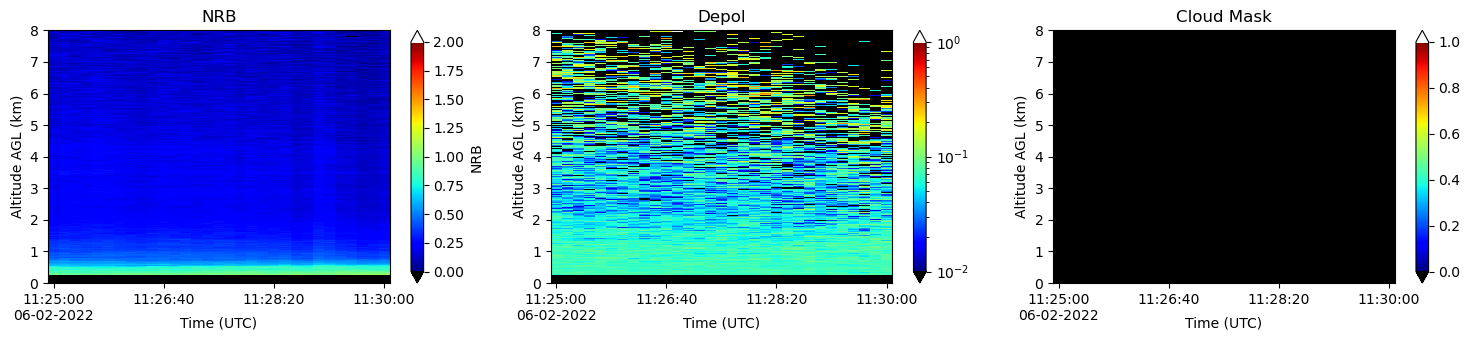

In [48]:
# Process MPL data

mpl_data, cloud_mask, cloud_free_column, high_snr_depol, fig1, axs1 = tracer_avp_processing.process_mpl_data(
    start_time, end_time,                       # Input start_time and end_time
    input_folder = arm_mpl_dir_path,            # Input raw mpl file folder path
    ap_file = arm_mpl_afterpulse_binary_path,   # Input afterpulse binary path
    ov_file = arm_mpl_overlap_binary_path,      # Input overlap binary path
    dt_file = arm_mpl_deadtime_binary_path,     # Input deadtime binary path
    suffix = '*.mpl',                           # ARM MPL also produces '.mpl2' files, likely from the wide-angle receiver. Here we only use '.mpl' and ignore '.mpl2'.
    time_resolution = 10, mov_avg_win = None,   # We match the raw data resolution here at 10 seconds, aligning the data to a regular temporal grid. Therefore, no moving average is needed. 
                                                # However, if downsampling, for example, to 60 seconds, a moving average window of 6 should be applied to preserve temporal representativeness.
                                                # By the way, the interpolation step also detects gaps in the data and represent them as nan.
    scale_num = 30,                             # number of continuous wavelet transform (CWT) scales. Sets the largest wavelet window (~30 range bins)
    length_treshold = 25,                       # minimum length (in range bins) a CWT ridge/trough must persist before it can qualify as a cloud edge
    value_treshold = 1.5,                       # minimum absolute CWT-coefficient of a ridge/trough at the coarsest scale; filters out weak, noisy features
    edge_treshold = 1.4,                        # NRB (or smoothed NRB) amplitude cutoff used to trim the coarse CWT boundaries to their exact bottoms/tops
    contain_cloud_treshold = 1.45,              # NRB level that must be met by at least a short run of bins to declare that “there is cloud between two candidate bottoms”
    cloud_pixel_number_treshold = 1,            # how many consecutive bins must exceed contain_cloud_treshold to bridge a gap (1 keeps everything, 2+ removes speckle)
    snr_treshold = 5,                           # Quality screen on raw MPL data. Any gate whose signal-to-noise ratio is < 5 is set to NaN. That prevents low-quality bins from influencing later steps (wavelet transform, cloud finding, retrievals).
    not_a_cloud_treshold = 1.4,                 # Last-pass intensity veto.  After the wavelet/CWT logic has built a tentative cloud mask, every bin whose (smoothed) NRB is still < 1.4 is forced to “not-cloud.” 
    find_cloud_range = calibration_range,       # Highest altitude to find cloud. Only do cloud masking here below calibration_range (8 km).
    blind_zone = blind_zone,                          # MPL has a blind zone of about 250 m near the ground.
    fig = None, axs = None, figsize = (15,3.5), # if None is supplied to fig and axs, this function will create a figure and axs, which are then returned.
    plot_range_max = 8,   
    savefig = True, showplot = True, 
    output_folder = output_dir_path)            # set other behavior of this function.

### Process ARM radiosonde data

| Input             | Type / Shape                          | Detail                                                                                   |
|-----------------------|----------------------------------------|--------------------------------------------------------------------------------------------------|
| `start_time`          | `numpy.datetime64` / datetime-like     | Start of averaging window (UTC).                                                                |
| `end_time`            | `numpy.datetime64` / datetime-like     | End of averaging window (UTC).                                                                  |
| `mpl_range`           | `ndarray` `(n_range,)`                 | Height grid used by MPL (km). Radiosonde profiles are mapped onto this grid.                    |
| `input_folder`        | `str` or `pathlib.Path`                | Directory containing ARM **sondewnpn** files to search within the time window.                  |
| `vertical_offset`     | `float`                                | Height offset applied to radiosonde altitude (km). Usually set to 0                             |
| `wavelength`          | `float`                                | Lidar wavelength (nm if you pass 532; function converts to µm internally for Rayleigh calc).    |
| `fig`                 | `matplotlib.figure.Figure` or `None`   | Existing figure handle. If `None`, a new figure is created.                                      |
| `axs`                 | array/list of `matplotlib.axes.Axes` or `None` | Existing axes. If `None`, three new subplots are created.                                 |
| `figsize`             | `tuple(float, float)`                  | Size of the created figure (inches) if `fig`/`axs` are `None`.                                  |
| `savefig`             | `bool`                                 | Save the radiosonde profile figure to disk.                                                     |
| `showplot`            | `bool`                                 | Display the plot interactively (`plt.show()`).                                                  |
| `output_folder`       | `str` or `pathlib.Path`                | Folder where the figure will be saved if `savefig=True`.                                        |
| `fig_name`            | `str` or `None`                        | Filename for the saved figure; autogenerated if `None`.                                         |

&nbsp;

| Output            | Type / Shape                         | Detail                                                           |
|-----------------|--------------------------------------|--------------------------------------------------------------------|
| `sonde_beta2`   | `ndarray` `(n_range,)`                | Molecular (Rayleigh) backscatter coeff. on `mpl_range` (km⁻¹ sr⁻¹). |
| `rh_interpolator` | `scipy.interpolate.interp1d`        | Function: height (km) → RH (%) on-demand, matching `mpl_range` grid. |
| `fig2`          | `matplotlib.figure.Figure`            | Figure handle for the 3-panel radiosonde profile plot.             |
| `axs2`          | array/list of 3 `Axes`                | Axes for RH, pressure, and temperature vs. height.                  |


Processing ARM Radiosonde Data
ARM Radiosonde Files: /Users/bochen/TAMU/mplavp/example_data/arm_radiosonde/housondewnpnM1.b1.20220602.112900.cdf
ARM Raidosonde Launch Time is 2022-06-02T11:29:00


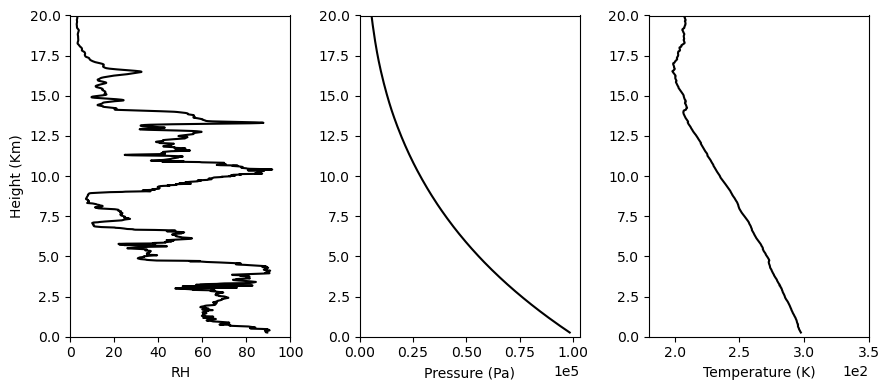

In [49]:
sonde_beta2, rh_interpolator, fig2, axs2 \
                = tracer_avp_processing.process_arm_radiosonde_data(start_time, end_time, mpl_data.range, input_folder = arm_radiosonde_dir_path,
                                                                    savefig = False, showplot = True, output_folder = output_dir_path)

### Process ARM merged size distribution data


| Input         | Type / Shape                         | Detail                                                           |
|-------------------|--------------------------------------|--------------------------------------------------------------|
| `start_time`      | `numpy.datetime64` / datetime-like   | Start of averaging window (UTC).                             |
| `end_time`        | `numpy.datetime64` / datetime-like   | End of averaging window (UTC).                                     |
| `input_folder`    | `str` or `pathlib.Path`              | Directory with ARM `houmergedsmpsaps*` netCDF files.               |
| `figsize`         | `tuple(float, float)`                | Size of figure if a new plot is created.                           |
| `fig`             | `matplotlib.figure.Figure` or `None` | Existing figure handle; new one made if `None`.                    |
| `axs`             | list/array of `matplotlib.axes.Axes` or `None` | Existing axes; two new subplots made if `None`.            |
| `savefig`         | `bool`                               | Save plot to disk if `True`.                                       |
| `showplot`        | `bool`                               | Call `plt.show()` if `True`.                                       |
| `output_folder`   | `str` or `pathlib.Path`              | Where to save the figure when `savefig=True`.                      |
| `fig_name`        | `str` or `None`                      | File name for saved figure (auto-generated if `None`).             |
                                                                                                   
&nbsp;

| Output                  | Type / Shape              | Detail                                                              |
|-----------------------|---------------------------|------------------------------------------------------------------|
| `merged_diameter`     | `ndarray` `(n_bins,)`     | Mobility diameter grid (nm).                                          |
| `mean_dndlogdp`       | `ndarray` `(n_bins,)`     | Mean size distribution \(dN/dlogDp\) over the window (cm⁻³).          |
| `total_concentration` | `float`                   | Integrated number concentration over all bins (cm⁻³).                 |
| `sem_concentration`   | `float`                   | Standard error of the mean concentration (cm⁻³).                      |
| `fig`                 | `matplotlib.figure.Figure`| Figure for the 2-panel size-distribution plot.                        |
| `axs`                 | array/list of `Axes`      | Two axes: (0) time–diameter heatmap, (1) mean spectrum line plot.     |

Processing ARM Size Distribution Data
ARM Sizedistribution Files: ['/Users/bochen/TAMU/mplavp/example_data/arm_sizedist/houmergedsmpsapsM1.c1.20220602.000000.nc', '/Users/bochen/TAMU/mplavp/example_data/arm_sizedist/houmergedsmpsapsM1.c1.20220603.000000.nc']


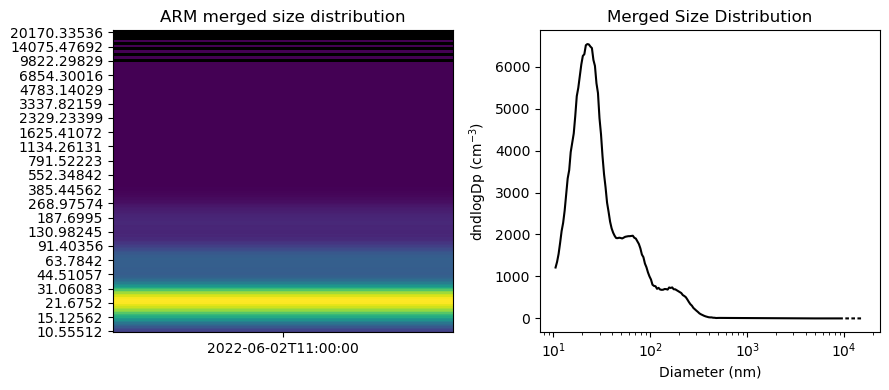

In [50]:
merged_diameter, mean_dndlogdp, total_concentration, sem_concentration, fig3, axs3 \
            = tracer_avp_processing.process_arm_mergedsizedist_data(
                start_time, end_time, input_folder = arm_sizedist_dir_path,
                savefig = False, showplot = True, output_folder = output_dir_path)

### Process ACSM derived kappa

ACSM derived kappa of AMF-1 site during the TRACER campaign is provided by Dr. Maria Zawadowicz.

read_ACSM_kappa(...) loads the ACSM κ file, finds the rows overlapping your [start_time, end_time] window, and returns the time-weighted geometric mean κ for that period. Geometric standard deviation is set as 1.5. We use geometric mean kappa here because the kappa values satisfy a log-normal (multiplicative) distribution, so the geometric mean is the proper central tendency and avoids bias from very high or low values.

In [51]:
gmean_kappa = tracer_avp_processing.read_ACSM_kappa(start_time, end_time, arm_acsm_kappa_csv_path)
gstd_kappa = 1.5
print(f'The geometric standard deviation kappa is {gstd_kappa}')

The geometric mean kappa is 0.27744880602670907
The geometric standard deviation kappa is 1.5


### Calculate Humidification Factor

calculate_humidification_factor computes a lidar hygroscopic growth correction factor (HF) vs. RH using κ–Köhler theory. It evaluates HF for the geometric-mean κ and its ±1 σ_g bounds (via gstd_kappa), normalizes to a “dry” RH, builds cubic-spline interpolators (mean/high/low), and optionally plots/shades the envelope.

| Input                | Type / Shape                          | Detail                                                                          |
|----------------------|----------------------------------------|--------------------------------------------------------------------------------|
| `start_time`         | datetime-like                          | Start of the averaging window (UTC).                                           |
| `end_time`           | datetime-like                          | End of the averaging window (UTC).                                             |
| `gmean_kappa`        | `float`                                | Geometric-mean hygroscopicity κ.                                               |
| `gstd_kappa`         | `float`                                | Geometric std. factor for κ (e.g., 1.5 → ±50%).                                |
| `merged_sizes`       | `ndarray` `(n_bins,)`                  | Particle diameters (nm).                                                       |
| `mean_dndlogdp`      | `ndarray` `(n_bins,)`                  | Mean size distribution \(dN/d\log D_p\) (cm⁻³).                                |
| `rh_lim`             | `float` (0–1)                          | RH upper limit shown / evaluated (e.g., 0.95).                                 |
| `rh_dry`             | `float` (0–1)                          | “Dry” RH used for normalization (HF=1 below/at this).                          |
| `wavelength`         | `float`                                | Lidar wavelength (nm).                                                         |
| `ri_real`            | `float` or `list[float]`               | Real part(s) of refractive index to bracket HF uncertainty.                    |
| `ri_imaginary`       | `float`                                | Imaginary part of refractive index.                                            |
| `figsize`            | `tuple(float, float)`                  | Size of created figure if `fig`/`axs` are `None`.                              |
| `fig`                | `matplotlib.figure.Figure` or `None`   | Existing figure; new one made if `None`.                                       |
| `axs`                | `matplotlib.axes.Axes` or `None`       | Existing axis; new one made if `None`.                                          |
| `savefig`            | `bool`                                 | Save plot to disk if `True`.                                                   |
| `showplot`           | `bool`                                 | Call `plt.show()` if `True`.                                                   |
| `output_folder`      | `str` / `pathlib.Path`                 | Directory to save figure when `savefig=True`.                                  |
| `fig_name`           | `str` or `None`                        | Filename for saved figure (auto if `None`).                                    |

&nbsp;

| Output             | Type / Shape                    | Detail                                                                        |
|--------------------|----------------------------------|-------------------------------------------------------------------------------|
| `hf_interp`        | `scipy.interpolate.CubicSpline` | Mean HF(RH): callable RH∈[0,1] → factor (unitless).                           |
| `hf_high_interp`   | `scipy.interpolate.CubicSpline` | Upper HF bound using κ·gstd_kappa.                                            |
| `hf_low_interp`    | `scipy.interpolate.CubicSpline` | Lower HF bound using κ/gstd_kappa.                                            |
| `fig`              | `matplotlib.figure.Figure`      | Figure handle for the HF plot.                                                |
| `axs`              | `matplotlib.axes.Axes`          | Axis containing the HF curve and shaded uncertainty band.                     |

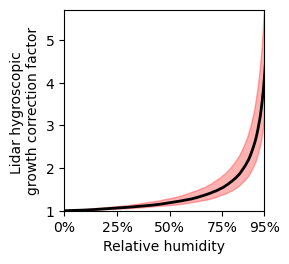

(1.0, 10.0)

In [52]:
fig4, axs4 = plt.subplots(nrows=1, ncols=1, figsize=(3.1,3))

hf_interp, hf_high_interp, hf_low_interp, _fig, _axs  \
            = tracer_avp_processing.calculate_humidification_factor(
                start_time, end_time, 
                gmean_kappa, gstd_kappa,
                merged_diameter, mean_dndlogdp,
                rh_lim = 0.95, rh_dry = 0,
                fig = fig4, axs = axs4,
                wavelength = 532, ri_real = [1.45, 1.5], ri_imaginary = 0,
                savefig = True, showplot = True, 
                output_folder = output_dir_path, 
                fig_name = f'{start_time} {end_time} Humidification factor')

axs4.set_ylim(1, 10)

### Retrieve Aerosol Backscatter Profile

#### `mpl_profile_prep`

Prepares cloud-free, averaged, normalized, and wavelet-smoothed lidar NRB & depolarization profiles.

| Input | Type / Shape | Detail |
|------|---------------|--------|
| `start_time` | datetime-like | Start of averaging window (UTC). |
| `end_time` | datetime-like | End of averaging window (UTC). |
| `cloud_free_column` | ndarray (t,) | 1 for cloud-free profile indices, 0 otherwise. |
| `mpl_range` | ndarray (z,) | Altitude grid AGL. |
| `copol_nrb` | ndarray (t,z) | Co-polarized NRB (used). |
| `crosspol_nrb` | ndarray (t,z) | Cross-polarized NRB (kept/optional). |
| `depol` | ndarray (t,z) | Linear depolarization ratio. |
| `nb_factor` | float | Wavelet smoothing strength. |
| `merge_range` | float | Vertical merge length for smoothing. Only smooth above this merge_range|
| `wavelet` | str | Wavelet family name (e.g., "bior3.5"). |
| `figsize` | tuple(float,float) | Size if creating a new figure. |
| `fig`, `axs` | Figure / Axes or None | Reuse existing or create new (expects 2 axes). |
| `ylim` | float | Plot upper y-limit. |
| `nrb_color`, `smoothed_color`, `depol_color` | str | Line colors. |
| `savefig` | bool | Save figure to disk. |
| `showplot` | bool | Call `plt.show()`. |
| `output_folder` | str / Path | Directory for saved figure. |
| `fig_name` | str or None | Filename; auto if None. |

&nbsp;

| Output | Type / Shape | Detail |
|--------|---------------|--------|
| `normalized_nrb` | ndarray (z,) | Cloud-free mean NRB normalized to surface. |
| `nrb_smoothed` | ndarray (z,) | Wavelet-smoothed NRB. |
| `cloudfree_depol_mean` | ndarray (z,) | Mean depol ratio over cloud-free times. |
| `fig` | matplotlib.figure.Figure | Figure handle. |
| `axs` | ndarray[Axes] (2,) | Axes for NRB / depol plots. |


#### `retrieve_backscatter`

Runs Fernald inversion, applies hygroscopic correction, estimates uncertainties, extends into blind zone, and plots aerosol backscatter and RH profiles.

| Input | Type / Shape | Detail |
|------|---------------|--------|
| `start_time`, `end_time` | datetime-like | Processing window. |
| `mpl_range` | ndarray (z,) | Original altitude grid. |
| `nrb_smoothed` | ndarray (z,) | Smoothed NRB from `mpl_profile_prep`. |
| `beta2` | ndarray (z,) | Molecular backscatter profile. |
| `rh_interpolator` | callable | RH(z) interpolator. |
| `hf_interp`, `hf_high_interp`, `hf_low_interp` | callable | Humidification factor splines (mean / high / low). |
| `calibration_range` | float | Reference altitude for Fernald calibration. |
| `blind_zone` | float | Lowest range excluded from inversion. |
| `RH_upper_limit` | float | RH cap to avoid cloud contamination. |
| `aerosol_lr` | list[float] | Tested lidar ratios. |
| `calibration_beta1_ratio` | list[float] | Fraction of β1 used at calibration height. |
| `rh_smooth_weight` | float or False | Spline smoothness for RH. |
| `ashf_smooth_factor` | float or False | Optional smoothing of HF curves. |
| `figsize` | tuple(float,float) | Size if new plot. |
| `fig`, `axs` | Figure / Axes or None | Reuse or create (expects 2 axes). |
| `savefig`, `showplot` | bool | Save and/or show plot. |
| `output_folder`, `fig_name` | str / Path, str or None | Output path and filename. |

&nbsp;

| Output | Type / Shape | Detail |
|--------|---------------|--------|
| `bck_results` | list[dict] | Raw inversion outputs for each LR/β1 ratio combo. |
| `inv_range` | ndarray (z_inv,) | Inversion altitude grid (excludes blind zone). |
| `dry_aerosol_backscatter_coeffs` | ndarray (n_tests,z_inv) | Hygroscopic-corrected aerosol β₁ profiles. |
| `bcksca_coeff_mae` | tuple(ndarray, ndarray, ndarray) | Mean, −err, +err for total backscatter. |
| `aerosol_bcksca_mae` | tuple(...) | Mean, −err, +err for wet aerosol backscatter. |
| `dry_aerosol_bcksca_mae` | tuple(...) | Mean, −err, +err for dry aerosol backscatter. |
| `smotothed_rh_profile` | ndarray (z_inv,) | Smoothed RH on inversion grid. |
| `blind_inv_range` | ndarray | Altitude grid inside blind zone. |
| `blind_profile_mae` | tuple(...) | Mean, −err, +err for extrapolated blind-zone β₁. |
| `dry_polyfit_coefficients_list` | list[array_like] | Quadratic fit coeffs used for blind-zone extension. |
| `fig`, `axs` | Figure, ndarray[Axes] | Plot handles for backscatter/RH figures. |

Four plots are created:

- Normalized relative backscatter (NRB)
- Linear depolarization ratio
- total and rayleigh backscatter
- Aerosol backscatter, dry aerosol backscatter

number of cloud free nrb profile (31, 2173)
2022-06-02T11:25 to 2022-06-02T11:30 preparing NRB and Depol profile
number of dry_aerosol_backscatter_coeffs columns 120


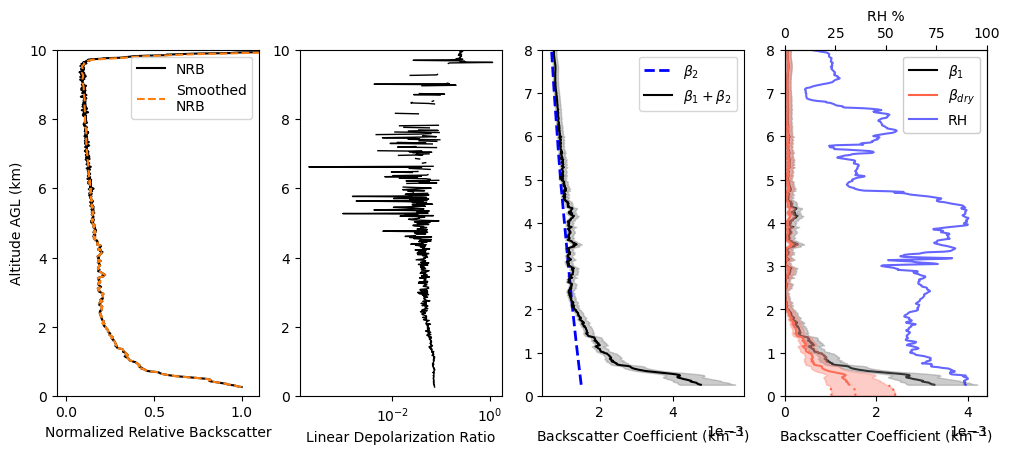

In [66]:
fig5, axs5 = plt.subplots(nrows=1, ncols=4, figsize=(12,4.5))

# provide smoothing and 
normalized_nrb, nrb_smoothed, cloudfree_depol_mean, _fig, _axs  \
            = tracer_avp_processing.mpl_profile_prep(start_time, end_time, 
                                                cloud_free_column,
                                                mpl_data.range, mpl_data.interpolated_nrb_copol, 
                                                mpl_data.interpolated_nrb_crosspol, high_snr_depol,
                                                nb_factor=0.01,                                    # the NRB profile is rather smooth therefore the smoothing factor is low.
                                                merge_range = 5.5,                                 
                                                wavelet = "bior3.5",  
                                                ylim = 10,
                                                fig = fig5, axs =[axs5[0], axs5[1]],
                                                savefig = False, showplot = False, output_folder = output_dir_path)


bck_results, inv_range, dry_aerosol_backscatter_coeffs, bcksca_coeff_mae, \
        aerosol_bcksca_coeff_mae, dry_aerosol_bcksca_coeff_mae, \
        smotothed_rh_profile, blind_inv_range, blind_profile_mae, dry_polyfit_coefficients_list, \
        fig, axs = tracer_avp_processing.retrieve_backscatter(start_time, end_time, 
                                                mpl_data.range, nrb_smoothed, sonde_beta2,
                                                rh_interpolator, hf_interp, hf_high_interp, hf_low_interp,
                                                calibration_range = calibration_range, blind_zone=blind_zone,
                                                aerosol_lr = [20,30,40,50,60,70,80,90],
                                                calibration_beta1_ratio = [0, 0.05, 0.1, 0.15, 0.2],
                                                RH_upper_limit = RH_upper_limit, 
                                                fig = fig5, axs = [axs5[2],axs5[3]],
                                                rh_smooth_weight = False, ashf_smooth_factor = 30,
                                                savefig = True, showplot = False, output_folder = output_dir_path)


Figure 5 (subplot 1) displays a clean NRB profile with very little noise. The pronounced peak near 10 km may arises from residual cloud returns that the cloud-masking algorithm did not completely eliminate. Because our analysis only extends to 8 km, this residual cloud signal does not affect the results.

From Fig. 5 (subplot 2), the volume depolarization ratio remains nearly constant with height. Because more spherical particles yield lower depolarization values while non-spherical particles (e.g., dust) raise them, this uniform profile indicates that aerosol shape—and therefore composition—does not differ appreciably throughout the column.

From Fig. 5 (subplot 4), we observe that applying the hygroscopic‐growth correction markedly lowers the aerosol backscatter coefficient from the surface up to about 1 km. The method also successfully reduces the slight backscatter enhancement near 4 km, indicating that this feature stems primarily from high relative humidity at that altitude rather than from a distinct elevated aerosol layer. The resulting dry aerosol backscatter profile will serve as the basis for deriving the aerosol concentration vertical profile.

### Retrieve aerosol vertical profile

Builds aerosol (and optional CCN/INP) concentration profiles from dry backscatter, propagates uncertainties (±), extends into the blind zone using prefit polynomials, and optionally plots them.

| Input | Type / Shape | Detail |
|------|---------------|--------|
| `start_time`, `end_time` | datetime-like | Processing window. |
| `inv_range` | ndarray (z_inv,) | Inversion altitude grid above blind zone. |
| `dry_aerosol_backscatter_coeffs` | ndarray (n_tests, z_inv) | Hygroscopic-corrected aerosol β₁ sets. |
| `aerosol_concentration` | float | Surface aerosol number concentration. |
| `aerosol_concentration_uncertainty` | float | ± uncertainty on the surface concentration. |
| `ss_array` | list[float] or None | Supersaturation values for CCN profiles. |
| `average_N_CCN` | ndarray (n_ss,) or None | Mean CCN at each supersaturation. |
| `uncertainty_N_CCN` | ndarray (n_ss,) or None | ± CCN uncertainties. |
| `inp_temp_list` | list[float] or None | Temperatures for INP estimates. |
| `inp_conc_list` | list[float] or None | INP concentrations matching `inp_temp_list`. |
| `dry_polyfit_coefficients_list` | list[array_like] | Quadratic coeffs for blind-zone extension. |
| `blind_inv_range` | ndarray | Altitude grid inside blind zone. |
| `ylim` | float | Plot y-limit. |
| `figsize` | tuple | New fig size if `fig`/`axs` are None. |
| `fig`, `axs` | Figure / list[Axes] or None | Up to 4 axes: [aerosol/CCN full, aerosol-only, INP full, INP-only]. |
| `savefig`, `showplot` | bool | Save and/or show plot. |
| `blind_zone` | float | Height excluded from inversion. |
| `output_folder`, `fig_name` | str / Path, str or None | Where and how to save figure. |

&nbsp;

| Output | Type / Shape | Detail |
|--------|---------------|--------|
| `aerosol_profile_mae` | tuple(ndarray, ndarray, ndarray) | Mean, −err, +err aerosol profile above blind zone. |
| `blind_aerosol_profile_mae` | tuple(...) | Same, but for blind zone extension. |
| `CCN_maes` | list[tuple(...)] | One MAE tuple per supersaturation (inv_range). Empty if `ss_array` is None. |
| `blind_CCN_maes` | list[tuple(...)] | CCN MAEs in blind zone. |
| `INP_maes` | list[tuple(...)] | One MAE tuple per nonzero INP entry (inv_range). Empty if `inp_temp_list` is None. |
| `blind_INP_maes` | list[tuple(...)] | INP MAEs in blind zone. |
| `fig`, `axs` | Figure, list[Axes] | Handles for the generated/updated plots. |

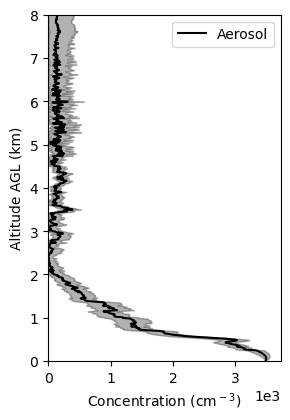

In [65]:
fig6, axs6 = plt.subplots(nrows=1, ncols=1, figsize=(3,4.5))

aerosol_profile_mae, blind_aerosol_profile_mae, CCN_maes, blind_CCN_maes, INP_maes, blind_INP_maes \
                    = tracer_avp_processing.aerosol_profiles(start_time, end_time,
                                        inv_range, dry_aerosol_backscatter_coeffs,
                                        total_concentration, sem_concentration,
                                        ss_array = None, average_N_CCN = None, uncertainty_N_CCN = None,  
                                        inp_temp_list = None, inp_conc_list = None, 
                                        dry_polyfit_coefficients_list = dry_polyfit_coefficients_list, 
                                        blind_inv_range = blind_inv_range,
                                        blind_zone=blind_zone,
                                        fig = fig6, axs = [axs6, None, None, None], output_folder = output_dir_path, savefig=True)


### Save data

In [55]:
tracer_avp_processing.output_data(start_time, end_time, "ARM",                                                        \
                                      normalized_nrb, nrb_smoothed, cloudfree_depol_mean, mpl_data.range,             \
                                      bcksca_coeff_mae, inv_range,                                                    \
                                      aerosol_bcksca_coeff_mae,                                                       \
                                      dry_aerosol_bcksca_coeff_mae,                                                   \
                                      smotothed_rh_profile,                                                           \
                                      merged_diameter, mean_dndlogdp,                                                 \
                                      None, None, None, None,                                                         \
                                      None, None,                                                                     \
                                      total_concentration, sem_concentration,                                         \
                                      gmean_kappa, gstd_kappa,                                                        \
                                      blind_inv_range, blind_profile_mae,                                             \
                                      aerosol_profile_mae, blind_aerosol_profile_mae, CCN_maes, blind_CCN_maes,       \
                                      output_dir_path)